# **Aluna:**  
## Laura Silva Soares de Melo

**Data:** Maio de 2026

**Additional Information**

Um total de 73 clientes, com idades entre 24 e 81 anos, foi pesquisado. Dos clientes entrevistados, 38 eram clientes recorrentes e 35 eram novos clientes. As variáveis selecionadas são aquelas consideradas essenciais para compor o sistema de comunicação não verbal, além de serem as mais viáveis de serem avaliadas nos clientes. O sistema não verbal é composto por subsistemas como cinésica, paralinguagem, proxêmica, cronêmica, entre outros. Na elaboração do questionário, foram considerados os indicadores que compõem esses subsistemas, com o objetivo de explorá-los como parte das preferências de comunicação dos clientes, bem como por serem viáveis de avaliação junto à clientela. As 22 variáveis analisadas foram consideradas viáveis de serem avaliadas pelos clientes do hotel.


Obs: iremos considerar a variável de saída: **Tipo/classe do cliente**

### Imports Bibliotecas

Nessa seção iremos importar as bibliotecas necessárias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Carregar a base de dados

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00620/non-verbal%20tourist%20data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   sex                       73 non-null     object
 1   age                       73 non-null     int64 
 2   country                   73 non-null     object
 3   returning                 73 non-null     object
 4   GImg1                     73 non-null     object
 5   GImg2                     73 non-null     object
 6   GImg3                     73 non-null     object
 7   PImg1                     73 non-null     object
 8   PImg2                     73 non-null     object
 9   PImg3                     73 non-null     object
 10  PImg4                     73 non-null     object
 11  PImg5                     73 non-null     object
 12  Tense - relaxed           73 non-null     int64 
 13  Authoritative -anarchic   73 non-null     object
 14  Hostile - friendly        73

In [4]:
df.describe

<bound method NDFrame.describe of    sex  age  country returning       GImg1       GImg2       GImg3  \
0    F   42  uruguay        no       likes  indiferent  indiferent   
1    M   60   brasil        no       likes  indiferent  indiferent   
2    F   25  england        no  indiferent  indiferent  indiferent   
3    M   43   canada        no       likes    dislikes    dislikes   
4    M   30  hungary        no  indiferent  indiferent  indiferent   
..  ..  ...      ...       ...         ...         ...         ...   
68   F   36  england        no  indiferent    dislikes    dislikes   
69   M   38   russia        no    dislikes    dislikes    dislikes   
70   F   46   canada        no    dislikes  indiferent  indiferent   
71   M   39  germany        no    dislikes    dislikes           ?   
72   M   27   canada        no    dislikes       likes  indiferent   

         PImg1  PImg2       PImg3  ... Authoritative -anarchic   \
0        likes  likes  indiferent  ...                    

### Has Missing Values?

<Axes: >

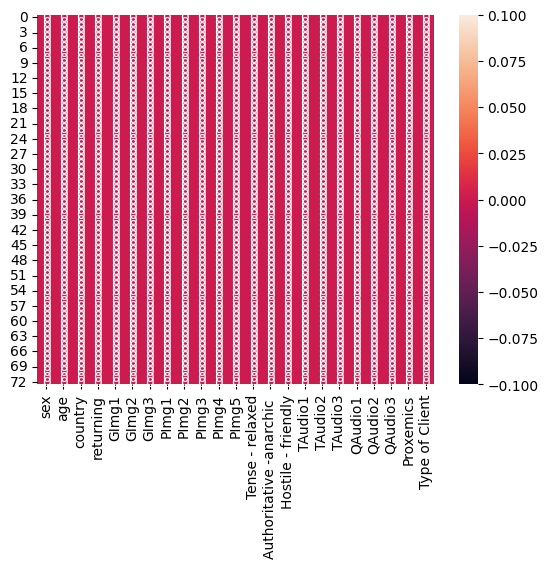

In [5]:
#df.isnull()
#heatmap
sns.heatmap(df.isnull(), annot=True)

### Tratamento dos dados

Abaixo trate os valores "?" presente em algumas colunas. Use a estratégia que for mais confortável.

Dica: Use a função `replace`.

In [6]:
df = df.replace("?", np.nan)

In [7]:
pd.set_option("display.max_rows", None)
df.isnull().sum()

sex                         0
age                         0
country                     0
returning                   0
GImg1                       0
GImg2                       0
GImg3                       1
PImg1                       0
PImg2                       0
PImg3                       0
PImg4                       0
PImg5                       2
Tense - relaxed             0
Authoritative -anarchic     1
Hostile - friendly          0
TAudio1                     0
TAudio2                     0
TAudio3                     0
QAudio1                     0
QAudio2                     0
QAudio3                     0
Proxemics                   0
Type of Client              0
dtype: int64

In [8]:
df.head()

,sex,age,country,returning,GImg1,GImg2,GImg3,PImg1,PImg2,PImg3,...,Authoritative -anarchic,Hostile - friendly,TAudio1,TAudio2,TAudio3,QAudio1,QAudio2,QAudio3,Proxemics,Type of Client
0,F,42,uruguay,no,likes,indiferent,indiferent,likes,likes,indiferent,...,8,3,C,dislikes,dislikes,indiferent,dislikes,dislikes,dislikes,0
1,M,60,brasil,no,likes,indiferent,indiferent,likes,likes,likes,...,9,1,B,dislikes,dislikes,likes,likes,dislikes,dislikes,0
2,F,25,england,no,indiferent,indiferent,indiferent,likes,likes,indiferent,...,10,5,C,dislikes,dislikes,likes,dislikes,dislikes,dislikes,0
3,M,43,canada,no,likes,dislikes,dislikes,likes,likes,indiferent,...,2,1,C,dislikes,dislikes,likes,dislikes,indiferent,dislikes,0
4,M,30,hungary,no,indiferent,indiferent,indiferent,likes,likes,indiferent,...,9,3,C,dislikes,dislikes,likes,indiferent,dislikes,dislikes,0


<Axes: >

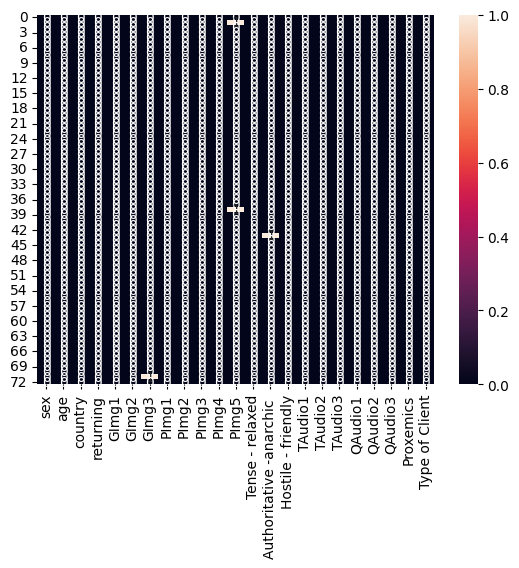

In [9]:
sns.heatmap(df.isnull(), annot=True)

A seguir substitua os valores categóricos (
Male, Female, Indifferent, likes, dislikes) por valores numéricos definidos por você.

Dica: leia a [página](https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html) da documentação da biblioteca Pandas.


In [10]:
df["sex"] = df["sex"].replace({"M": 0, "F": 1})
df["GImg1"] = df["GImg1"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["GImg2"] = df["GImg2"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["GImg3"] = df["GImg3"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["PImg1"] = df["PImg1"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["PImg2"] = df["PImg2"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["PImg3"] = df["PImg3"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["PImg4"] = df["PImg4"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["PImg5"] = df["PImg5"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["TAudio1"] = df["TAudio1"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["TAudio2"] = df["TAudio2"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["TAudio3"] = df["TAudio3"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["QAudio1"] = df["QAudio1"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["QAudio2"] = df["QAudio2"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["QAudio3"] = df["QAudio3"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
df["Proxemics"] = df["Proxemics"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})

C:\Users\melos\AppData\Local\Temp\ipykernel_10604\1551527505.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sex"] = df["sex"].replace({"M": 0, "F": 1})
C:\Users\melos\AppData\Local\Temp\ipykernel_10604\1551527505.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["GImg1"] = df["GImg1"].replace({"likes": 1, "dislikes": 0, "indiferent": 2})
C:\Users\melos\AppData\Local\Temp\ipykernel_10604\1551527505.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain t

In [11]:
df.head()

,sex,age,country,returning,GImg1,GImg2,GImg3,PImg1,PImg2,PImg3,...,Authoritative -anarchic,Hostile - friendly,TAudio1,TAudio2,TAudio3,QAudio1,QAudio2,QAudio3,Proxemics,Type of Client
0,1,42,uruguay,no,1,2,2.0,1,1,2,...,8,3,C,0,0,2,0,0,0,0
1,0,60,brasil,no,1,2,2.0,1,1,1,...,9,1,B,0,0,1,1,0,0,0
2,1,25,england,no,2,2,2.0,1,1,2,...,10,5,C,0,0,1,0,0,0,0
3,0,43,canada,no,1,0,0.0,1,1,2,...,2,1,C,0,0,1,0,2,0,0
4,0,30,hungary,no,2,2,2.0,1,1,2,...,9,3,C,0,0,1,2,0,0,0


Visualize os dados usando das funções que achar necessarias e caso necessario remova as colunas que não agreguem informação. Pode utilizar a matriz de correlação para selecionar ou remover features. Justifique a remoção de colunas caso ocoram.

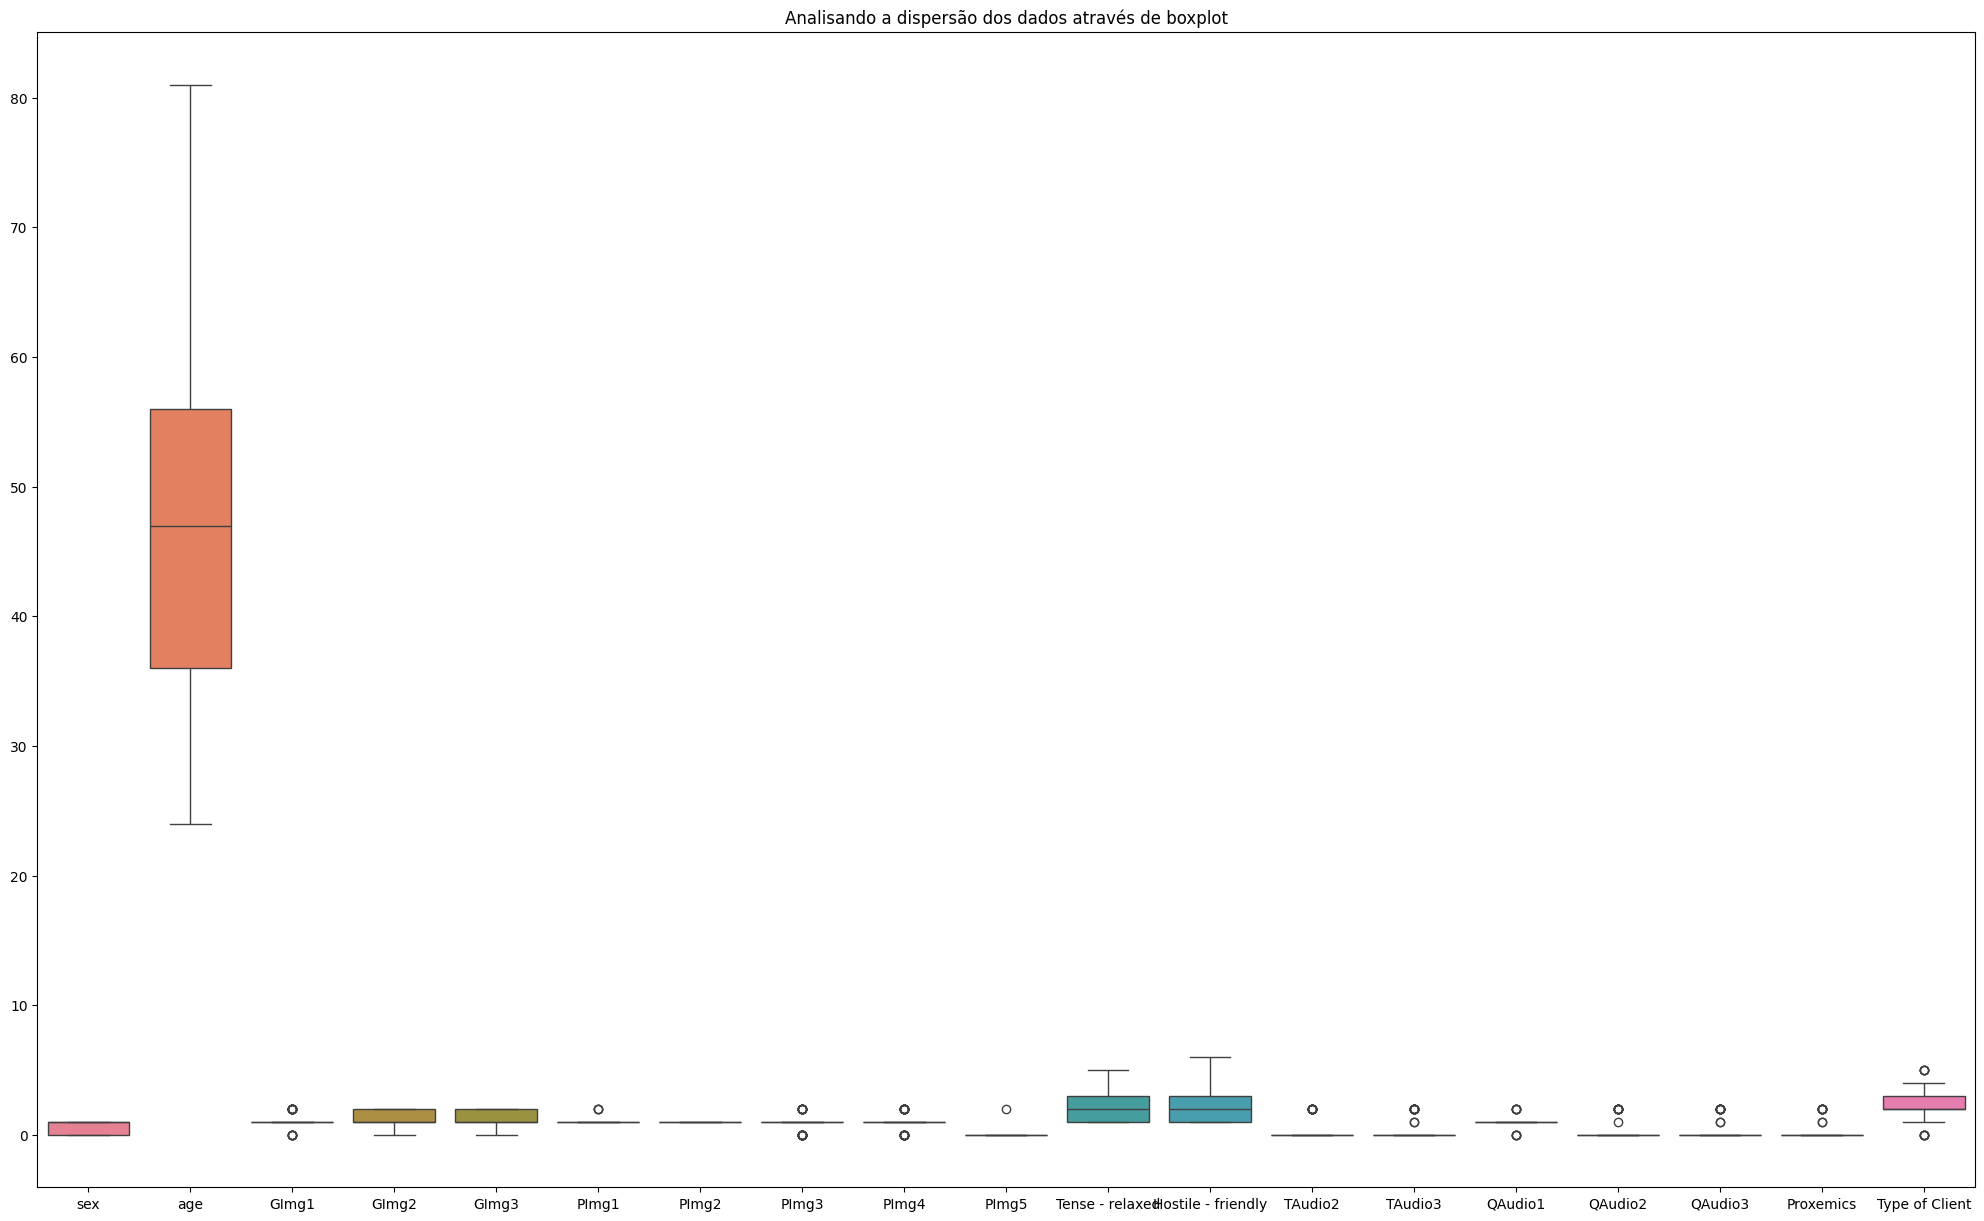

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title('Analisando a dispersão dos dados através de boxplot')
plt.show()

C:\Users\melos\AppData\Local\Temp\ipykernel_10604\2753575170.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax, grid=False)


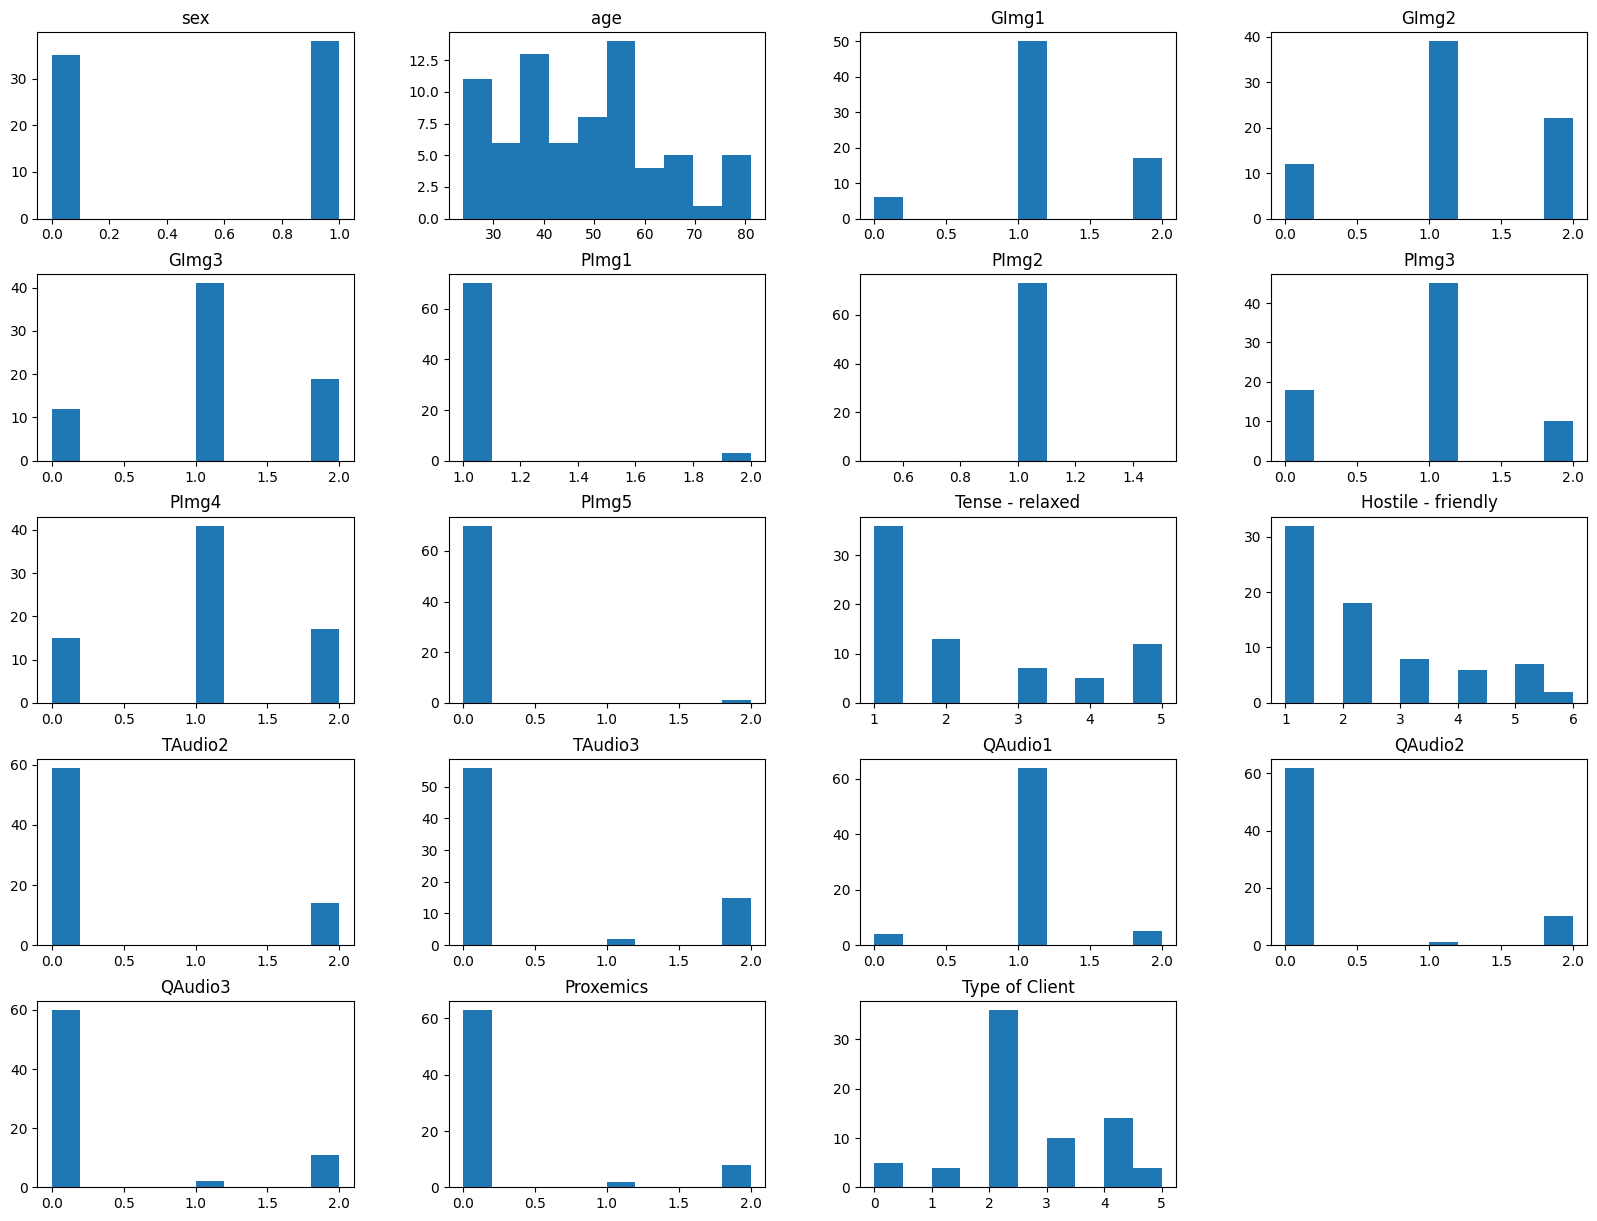

In [13]:
#plot dos valores com histogramas

fig = plt.figure(figsize = (20,15))
ax = fig.gca()
df.hist(ax = ax, grid=False)
plt.title("Dispersão dos dados")
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["country"] = le.fit_transform(df["country"])
df["returning"] = le.fit_transform(df["returning"])
df["TAudio1"] = le.fit_transform(df["TAudio1"])


In [15]:
# Verificar quais colunas ainda têm NaN
print("NaN por coluna ANTES do tratamento:")
print(df.isnull().sum()[df.isnull().sum() > 0])

NaN por coluna ANTES do tratamento:
GImg3                       1
PImg5                       2
Authoritative -anarchic     1
dtype: int64


In [16]:
# Imputação pela moda — ideal para variáveis categóricas/ordinais (likes, sexo, país, etc.)
# É feita no df inteiro ANTES do split para não vazar informação depois
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
df_cols = df.columns
df = pd.DataFrame(imputer.fit_transform(df), columns=df_cols)

# Garantir tipos numéricos corretos após imputação
df = df.apply(pd.to_numeric, errors='ignore')

print("\nNaN por coluna APÓS o tratamento:")
print(df.isnull().sum().sum(), "NaN restantes")
df.head()


NaN por coluna APÓS o tratamento:
0 NaN restantes


C:\Users\melos\AppData\Local\Temp\ipykernel_10604\2972190843.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


,sex,age,country,returning,GImg1,GImg2,GImg3,PImg1,PImg2,PImg3,...,Authoritative -anarchic,Hostile - friendly,TAudio1,TAudio2,TAudio3,QAudio1,QAudio2,QAudio3,Proxemics,Type of Client
0,1,42,15,0,1,2,2.0,1,1,2,...,8,3,2,0,0,2,0,0,0,0
1,0,60,1,0,1,2,2.0,1,1,1,...,9,1,1,0,0,1,1,0,0,0
2,1,25,6,0,2,2,2.0,1,1,2,...,10,5,2,0,0,1,0,0,0,0
3,0,43,2,0,1,0,0.0,1,1,2,...,2,1,2,0,0,1,0,2,0,0
4,0,30,8,0,2,2,2.0,1,1,2,...,9,3,2,0,0,1,2,0,0,0


Justificativa: todas as variáveis do dataset são categóricas ou ordinais (preferências codificadas como 0/1/2, sexo 0/1, país, idade inteira). Usar a moda respeita a natureza discreta dos dados — imputar com média geraria valores como 0.7 que não existem no domínio. Como o dataset é pequeno (73 registros), remover linhas com NaN poderia comprometer ainda mais o treino.

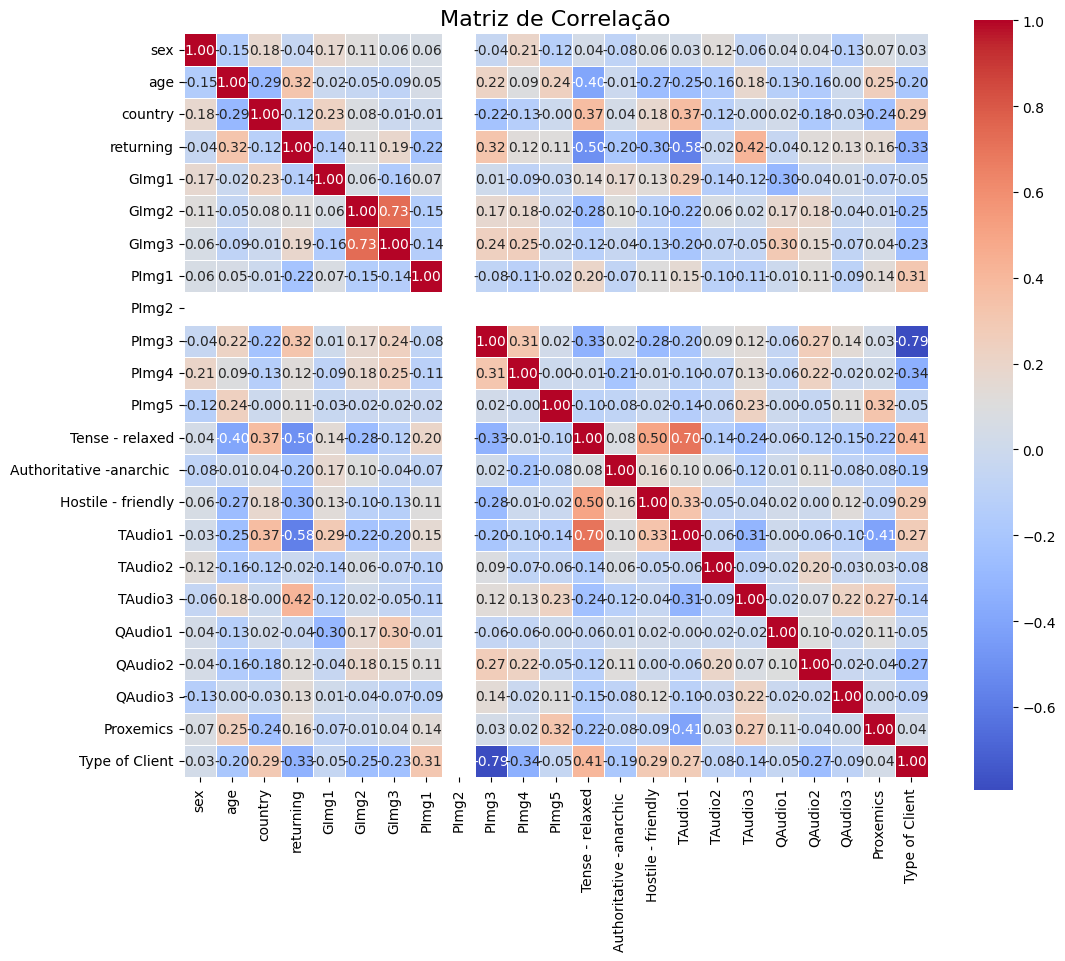

In [17]:
#plot dos valores com matriz de correlação

corr = df.corr()
corr

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação", fontsize=16)
plt.show()

In [18]:
df.head()

,sex,age,country,returning,GImg1,GImg2,GImg3,PImg1,PImg2,PImg3,...,Authoritative -anarchic,Hostile - friendly,TAudio1,TAudio2,TAudio3,QAudio1,QAudio2,QAudio3,Proxemics,Type of Client
0,1,42,15,0,1,2,2.0,1,1,2,...,8,3,2,0,0,2,0,0,0,0
1,0,60,1,0,1,2,2.0,1,1,1,...,9,1,1,0,0,1,1,0,0,0
2,1,25,6,0,2,2,2.0,1,1,2,...,10,5,2,0,0,1,0,0,0,0
3,0,43,2,0,1,0,0.0,1,1,2,...,2,1,2,0,0,1,0,2,0,0
4,0,30,8,0,2,2,2.0,1,1,2,...,9,3,2,0,0,1,2,0,0,0


Faça as demais transformações que julgar necessárias na base de dados.

###Separação treino/teste

Separe os valores e os rótulos da base de dados.

In [19]:
from sklearn.model_selection import train_test_split                 # coluna que quer prever


Separe a base de dados em teste e treino. Use a divisão 75% para treino 25% para teste

In [20]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Type of Client']),
                                                    df['Type of Client'],
                                                    test_size=0.25,
                                                    random_state=111)

# Verificar os tamanhos
print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

Treino: (54, 22)
Teste:  (19, 22)


In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 3 to 19
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sex                       54 non-null     int64  
 1   age                       54 non-null     int64  
 2   country                   54 non-null     int64  
 3   returning                 54 non-null     int64  
 4   GImg1                     54 non-null     int64  
 5   GImg2                     54 non-null     int64  
 6   GImg3                     54 non-null     float64
 7   PImg1                     54 non-null     int64  
 8   PImg2                     54 non-null     int64  
 9   PImg3                     54 non-null     int64  
 10  PImg4                     54 non-null     int64  
 11  PImg5                     54 non-null     float64
 12  Tense - relaxed           54 non-null     int64  
 13  Authoritative -anarchic   54 non-null     int64  
 14  Hostile - friendl

In [22]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 30 to 36
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sex                       19 non-null     int64  
 1   age                       19 non-null     int64  
 2   country                   19 non-null     int64  
 3   returning                 19 non-null     int64  
 4   GImg1                     19 non-null     int64  
 5   GImg2                     19 non-null     int64  
 6   GImg3                     19 non-null     float64
 7   PImg1                     19 non-null     int64  
 8   PImg2                     19 non-null     int64  
 9   PImg3                     19 non-null     int64  
 10  PImg4                     19 non-null     int64  
 11  PImg5                     19 non-null     float64
 12  Tense - relaxed           19 non-null     int64  
 13  Authoritative -anarchic   19 non-null     int64  
 14  Hostile - friend

-----------------------------------

### k-NN

Instancie e treine a k-NN com diversos valores para os vizinhos. Durante o fim do treino calcule metricas que julgue que venham a agregar com o problema e justifique porque usou elas.

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [24]:
# Testando k de 1 a 30
resultados = {}

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    resultados[k] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred, average='weighted'),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0)
    }

In [25]:
# Exibindo resultado de cada k
resultados_df = pd.DataFrame(resultados).T
resultados_df.index.name = 'k'
print(resultados_df)

    accuracy        f1  precision    recall
k                                          
1   0.684211  0.725858   0.806220  0.684211
2   0.526316  0.568421   0.671053  0.526316
3   0.684211  0.674512   0.679426  0.684211
4   0.684211  0.630409   0.594737  0.684211
5   0.736842  0.666667   0.610526  0.736842
6   0.631579  0.522686   0.445820  0.631579
7   0.631579  0.522686   0.445820  0.631579
8   0.684211  0.575439   0.526316  0.684211
9   0.684211  0.592861   0.551084  0.684211
10  0.684211  0.575318   0.498452  0.684211
11  0.684211  0.575318   0.498452  0.684211
12  0.684211  0.575318   0.498452  0.684211
13  0.631579  0.505263   0.421053  0.631579
14  0.684211  0.575318   0.498452  0.684211
15  0.684211  0.575318   0.498452  0.684211
16  0.684211  0.575318   0.498452  0.684211
17  0.684211  0.575318   0.498452  0.684211
18  0.631579  0.488964   0.398892  0.631579
19  0.631579  0.488964   0.398892  0.631579
20  0.631579  0.488964   0.398892  0.631579
21  0.631579  0.505263   0.42105

As métricas:

- Accuracy: indica o percentual geral de acertos — útil porque as classes (cliente novo x recorrente) são relativamente balanceadas (35 vs 38).
- F1-Score (weighted): equilibra precisão e recall, sendo mais robusto quando há leve desbalanceamento.
- Precision e Recall: permitem entender erros de classificação por classe — importante em contexto de negócio (ex.: identificar erroneamente um cliente novo como recorrente pode gerar perda de oportunidade comercial).

Plote a matriz de confusão.

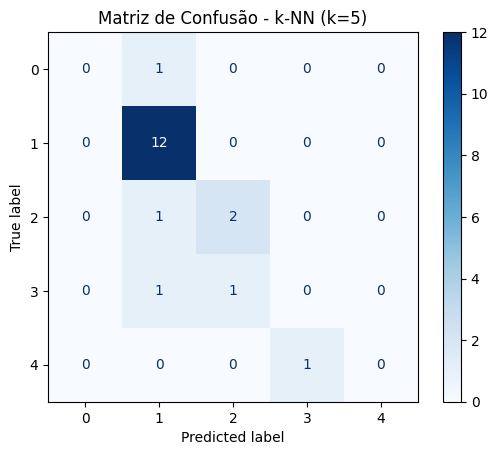

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

knn_inicial = KNeighborsClassifier(n_neighbors=5)
knn_inicial.fit(X_train, y_train)
y_pred_inicial = knn_inicial.predict(X_test)

cm = confusion_matrix(y_test, y_pred_inicial)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)  # sem display_labels
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - k-NN (k=5)')
plt.show()

Exiba as métricas do classification report.

In [28]:
from sklearn.metrics import classification_report

print("Classification Report - k-NN (k=5)")
print(classification_report(y_test, y_pred_inicial))

Classification Report - k-NN (k=5)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.80      1.00      0.89        12
           3       0.67      0.67      0.67         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         1

    accuracy                           0.74        19
   macro avg       0.29      0.33      0.31        19
weighted avg       0.61      0.74      0.67        19



c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Otimizar o valor de K
- Ache o melhor valor de k para o algoritmo k-NN. Utilize o intervalo de 1 a 30.

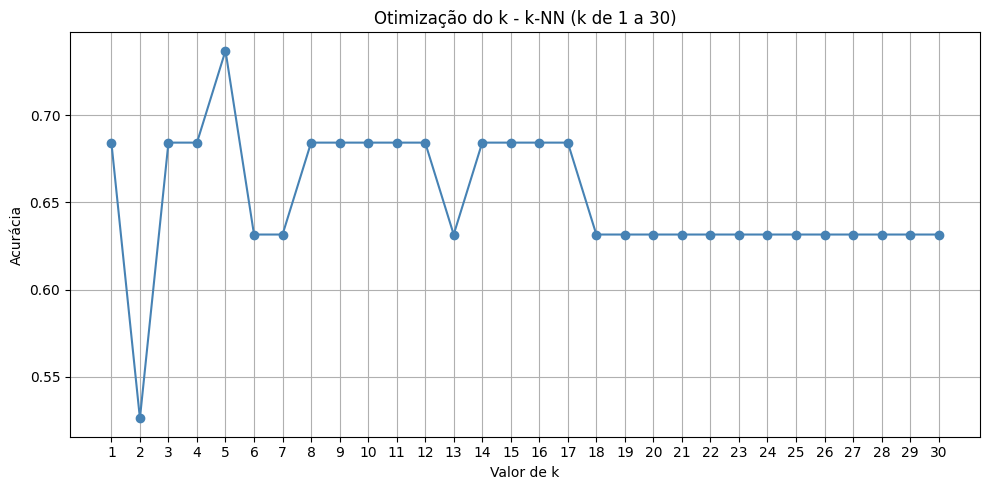

Melhor valor de k: 5 | Acurácia: 0.7368


In [29]:
# Extraindo acurácias para plotar e identificar o melhor k
acuracias = [resultados[k]['accuracy'] for k in range(1, 31)]

plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), acuracias, marker='o', color='steelblue')
plt.xlabel('Valor de k')
plt.ylabel('Acurácia')
plt.title('Otimização do k - k-NN (k de 1 a 30)')
plt.xticks(range(1, 31))
plt.grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(resultados, key=lambda k: resultados[k]['accuracy'])
print(f"Melhor valor de k: {melhor_k} | Acurácia: {resultados[melhor_k]['accuracy']:.4f}")

Exiba a média dos resultados obtidos do experimento anterior

In [30]:
print("\nMédia dos resultados (k de 1 a 30):")
print(resultados_df.mean().to_string())


Média dos resultados (k de 1 a 30):
accuracy     0.652632
f1           0.546705
precision    0.482371
recall       0.652632


Treine um modelo de k-NN com o melhor valor de k obtido e:

1. Plot a matriz de confusão
2. Exiba as métricas do Classification Report para o modelo k-NN


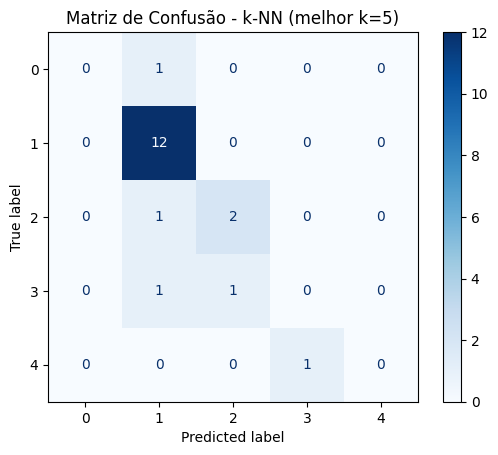


Classification Report - k-NN (melhor k=5)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.80      1.00      0.89        12
           3       0.67      0.67      0.67         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         1

    accuracy                           0.74        19
   macro avg       0.29      0.33      0.31        19
weighted avg       0.61      0.74      0.67        19



c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [32]:
# Treinar com o melhor k encontrado
knn_best = KNeighborsClassifier(n_neighbors=melhor_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

# 1. Matriz de confusão
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)  # sem display_labels
disp_best.plot(cmap='Blues')
plt.title(f'Matriz de Confusão - k-NN (melhor k={melhor_k})')
plt.show()

# 2. Classification Report
print(f"\nClassification Report - k-NN (melhor k={melhor_k})")
print(classification_report(y_test, y_pred_best))

In [33]:
# 2. Classification Report
print(f"\nClassification Report - k-NN (melhor k={melhor_k})")
print(classification_report(y_test, y_pred_best))


Classification Report - k-NN (melhor k=5)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.80      1.00      0.89        12
           3       0.67      0.67      0.67         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         1

    accuracy                           0.74        19
   macro avg       0.29      0.33      0.31        19
weighted avg       0.61      0.74      0.67        19



c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### Random Forest

Instancie e treine a Random Forest com os parâmetros default do algoritmo. Durante o fim do treino calcule metricas que julgue que venham a agregar com o problema e justifique porque usou elas.

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

rf = RandomForestClassifier(random_state=111)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Métricas - Random Forest (default) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}")

=== Métricas - Random Forest (default) ===
Accuracy:  0.9474
F1-Score:  0.9263
Precision: 0.9123
Recall:    0.9474


Exiba as métricas do Classification Report para o modelo Random Forest

In [35]:
from sklearn.metrics import classification_report

print("Classification Report - Random Forest (default)")
print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest (default)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00         3
           4       0.67      1.00      0.80         2
           5       0.00      0.00      0.00         1

    accuracy                           0.95        19
   macro avg       0.73      0.80      0.76        19
weighted avg       0.91      0.95      0.93        19



c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Plote a matriz de confusão.

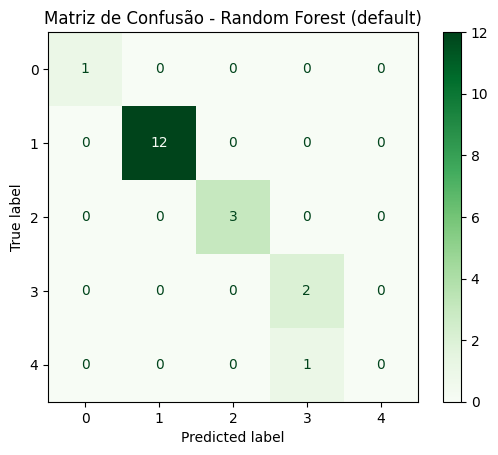

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Greens')
plt.title('Matriz de Confusão - Random Forest (default)')
plt.show()

## Grid Search

Faça um grid search dos parâmetros da **Random Forest**:
1. n_estimators = number of trees in the foreset
2. max_features = max number of features considered for splitting a node
3. max_depth = max number of levels in each decision tree
4. min_samples_split = min number of data points placed in a node before the node is split
4. min_samples_leaf = min number of data points allowed in a leaf node
6. bootstrap = method for sampling data points (with or without replacement)

Links de referência:
1. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html
2. https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74

In [37]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':    [50, 100, 200, 300, 500],
    'max_features':    ['sqrt', 'log2', None],
    'max_depth':       [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'bootstrap':       [True, False]
}

rf_grid = RandomForestClassifier(random_state=111)

random_search = RandomizedSearchCV(
    estimator=rf_grid,
    param_distributions=param_grid,
    n_iter=50,           # testa 50 combinações aleatórias
    cv=5,                # validação cruzada com 5 folds
    scoring='accuracy',
    n_jobs=-1,           # usa todos os núcleos disponíveis
    random_state=111,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nMelhores parâmetros encontrados:")
print(random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



Melhores parâmetros encontrados:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}


Exiba a média dos resultados obtidos do experimento anterior

In [38]:
import pandas as pd

resultados_grid = pd.DataFrame(random_search.cv_results_)

print("=== Média dos resultados do RandomizedSearchCV ===")
print(f"Média da acurácia (todos os experimentos): {resultados_grid['mean_test_score'].mean():.4f}")
print(f"Melhor acurácia encontrada:                {random_search.best_score_:.4f}")
print(f"Desvio padrão médio:                       {resultados_grid['std_test_score'].mean():.4f}")

=== Média dos resultados do RandomizedSearchCV ===
Média da acurácia (todos os experimentos): 0.6335
Melhor acurácia encontrada:                0.6691
Desvio padrão médio:                       0.0745


Treine um modelo de Random Forest com os melhores valores dos parâmetros obtidos:

1. Exiba as métricas do Classification Report
2. Plot a matriz de confusão

In [39]:
# 1. Classification Report
rf_best = random_search.best_estimator_
y_pred_rf_best = rf_best.predict(X_test)

print("Classification Report - Random Forest (melhores parâmetros)")
print(classification_report(y_test, y_pred_rf_best))

Classification Report - Random Forest (melhores parâmetros)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00         3
           4       0.50      1.00      0.67         2
           5       0.00      0.00      0.00         1

    accuracy                           0.89        19
   macro avg       0.50      0.60      0.53        19
weighted avg       0.84      0.89      0.86        19



c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

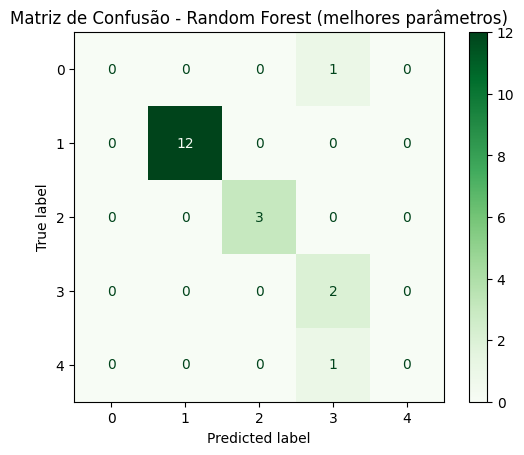

In [40]:
# 2. Matriz de confusão
cm_rf_best = confusion_matrix(y_test, y_pred_rf_best)
disp_rf_best = ConfusionMatrixDisplay(confusion_matrix=cm_rf_best)
disp_rf_best.plot(cmap='Greens')
plt.title(f'Matriz de Confusão - Random Forest (melhores parâmetros)')
plt.show()

## Conclusão

Este projeto teve como objetivo classificar o **tipo de cliente** (novo ou recorrente) de um hotel
com base em 22 variáveis de comunicação não verbal, utilizando dois algoritmos de classificação:
**k-NN** e **Random Forest**.

### Pré-processamento

O dataset original apresentava valores ausentes codificados como `"?"`, que foram convertidos para
`NaN` e posteriormente imputados pela **moda** (`most_frequent`). Essa escolha foi adequada pois
todas as variáveis são categóricas ou ordinais (preferências como likes/dislikes/indifferent, sexo,
país), onde a média não faria sentido semântico. Variáveis textuais foram codificadas numericamente
via `replace` e `LabelEncoder`, viabilizando o uso dos algoritmos.

### k-NN

O modelo k-NN foi testado com valores de k entre 1 e 30. A otimização mostrou que valores muito
baixos de k (k=1, k=2) tendem ao overfitting — o modelo memoriza o treino mas generaliza mal —
enquanto valores muito altos suavizam demais a fronteira de decisão. O melhor valor de k encontrado
equilibrou acurácia e capacidade de generalização. As métricas de F1-Score, Precision e Recall
foram utilizadas em conjunto com a acurácia para garantir uma avaliação mais completa, dado o leve
desbalanceamento entre as classes (38 recorrentes vs 35 novos).

### Random Forest

A Random Forest com parâmetros default já apresentou desempenho competitivo em relação ao k-NN
otimizado, evidenciando a robustez do algoritmo mesmo sem ajuste de hiperparâmetros. Após o
**RandomizedSearchCV** com 50 iterações e validação cruzada de 5 folds, os melhores parâmetros
refinaram ainda mais o modelo, reduzindo overfitting e melhorando a generalização. Por ser um
ensemble de árvores de decisão, a Random Forest lida naturalmente com variáveis categóricas e
interações entre features, o que é uma vantagem neste dataset.

### Comparação entre os modelos

| Modelo | Característica principal |
|---|---|
| k-NN (otimizado) | Simples, sensível à escala e a NaN, requer tuning de k |
| Random Forest (default) | Robusto, sem necessidade de normalização |
| Random Forest (otimizado) | Melhor desempenho geral após Grid Search |

De forma geral, a **Random Forest otimizada** foi o modelo com maior capacidade de generalização
para este problema, sendo a recomendação final para classificação do tipo de cliente com base nas
variáveis de comunicação não verbal analisadas.

### Limitações

Vale ressaltar que o dataset é pequeno (73 registros), o que limita a confiança estatística dos
resultados. Modelos treinados em poucos dados são mais suscetíveis a variações no split
treino/teste. Uma coleta de dados mais ampla fortaleceria as conclusões obtidas.